# H4-1 비모수 가설검정 — Wilcoxon / Mann-Whitney U

**전제 (앞선 노트북들에서 확정)**
- 안정구간: WEEK_NO 17~99, 초반/후반 각 10주
- 상위 20% 가구: 초반 지출액 기준 고정
- 정규성·등분산성 모두 기각 → 비모수 검정 사용
- 민감도 체크(N=8,10,12) 결과: "상위 지출가구는 후반에 지출이 줄고, 나머지는 늘어나는 수렴(convergence) 패턴"이 N에 관계없이 일관되게 나타남 → 진짜 패턴으로 판단, N=10 기준으로 본검정 진행

**검정 3개 (본페로니 보정, α=0.05/3≈0.0167 적용)**
- A. 상위20% 가구의 절대 지출액 변화가 유의한가 (Wilcoxon 부호순위검정, paired)
- B. 나머지80% 가구의 절대 지출액 변화가 유의한가 (Wilcoxon 부호순위검정, paired) — 비교 대조군
- C. 두 그룹의 증가폭(diff) 자체가 서로 다른가 (Mann-Whitney U, independent)

모든 검정에 **p-value + 효과크기 + 95% 신뢰구간**을 같이 보고한다.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy import stats

candidates = ["Malgun Gothic", "NanumGothic", "AppleGothic"]
available = {f.name for f in fm.fontManager.ttflist}
font_name = next((c for c in candidates if c in available), None)
if font_name:
    plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

pd.set_option('display.max_columns', 100)
np.random.seed(42)  # 부트스트랩 재현성

DATA_DIR = "data/"
tx = pd.read_csv(DATA_DIR + "transaction_data.csv")

STABLE_MIN_WEEK = 17
STABLE_MAX_WEEK = 99
EARLY_N = 10
TOP_X_PCT = 20
N_BOOT = 5000  # 부트스트랩 반복 횟수

tx_stable = tx[(tx["WEEK_NO"] >= STABLE_MIN_WEEK) & (tx["WEEK_NO"] <= STABLE_MAX_WEEK)].copy()


## 1. 데이터 준비 (이전 노트북과 동일한 정의)

In [2]:
early_window = tx_stable[
    (tx_stable["WEEK_NO"] >= STABLE_MIN_WEEK) &
    (tx_stable["WEEK_NO"] < STABLE_MIN_WEEK + EARLY_N)
]
late_window = tx_stable[
    (tx_stable["WEEK_NO"] > STABLE_MAX_WEEK - EARLY_N) &
    (tx_stable["WEEK_NO"] <= STABLE_MAX_WEEK)
]

sales_early = early_window.groupby("household_key")["SALES_VALUE"].sum().rename("sales_early")
sales_late  = late_window.groupby("household_key")["SALES_VALUE"].sum().rename("sales_late")

panel = pd.concat([sales_early, sales_late], axis=1).dropna()
panel["diff"] = panel["sales_late"] - panel["sales_early"]

cutoff_value = panel["sales_early"].quantile(1 - TOP_X_PCT/100)
panel["group"] = np.where(panel["sales_early"] >= cutoff_value, "상위20%", "나머지80%")

top_diff  = panel.loc[panel["group"] == "상위20%", "diff"].values
rest_diff = panel.loc[panel["group"] == "나머지80%", "diff"].values

print(f"상위20%: n={len(top_diff)}, 평균diff={top_diff.mean():.2f}, 중앙값diff={np.median(top_diff):.2f}")
print(f"나머지80%: n={len(rest_diff)}, 평균diff={rest_diff.mean():.2f}, 중앙값diff={np.median(rest_diff):.2f}")

N_TESTS = 3
ALPHA = 0.05
ALPHA_ADJ = ALPHA / N_TESTS
print(f"\n본페로니 보정 유의수준: {ALPHA_ADJ:.4f} (원래 {ALPHA} / {N_TESTS}개 검정)")


상위20%: n=419, 평균diff=-111.49, 중앙값diff=-131.45
나머지80%: n=1676, 평균diff=102.74, 중앙값diff=36.49

본페로니 보정 유의수준: 0.0167 (원래 0.05 / 3개 검정)


## 2. 효과크기 · 신뢰구간 계산용 헬퍼 함수

- Wilcoxon 부호순위검정의 효과크기: rank-biserial correlation (r = Z / sqrt(N))
- Mann-Whitney U의 효과크기: rank-biserial correlation + 공통언어효과크기(common language effect size)
- 신뢰구간은 전부 **부트스트랩**(중앙값 차이 기준, 5000회 재표본)으로 계산 — 비모수 검정과 일관된 방식


In [3]:
def bootstrap_ci_median(x, n_boot=N_BOOT, ci=95):
    """단일 표본 중앙값의 부트스트랩 신뢰구간"""
    boot_medians = np.array([
        np.median(np.random.choice(x, size=len(x), replace=True))
        for _ in range(n_boot)
    ])
    lo, hi = np.percentile(boot_medians, [(100-ci)/2, 100-(100-ci)/2])
    return lo, hi

def bootstrap_ci_median_diff(x, y, n_boot=N_BOOT, ci=95):
    """두 독립표본 간 중앙값 차이(median(x)-median(y))의 부트스트랩 신뢰구간"""
    boot_diffs = np.empty(n_boot)
    for i in range(n_boot):
        bx = np.random.choice(x, size=len(x), replace=True)
        by = np.random.choice(y, size=len(y), replace=True)
        boot_diffs[i] = np.median(bx) - np.median(by)
    lo, hi = np.percentile(boot_diffs, [(100-ci)/2, 100-(100-ci)/2])
    return lo, hi

def wilcoxon_effect_size(x):
    """Wilcoxon 부호순위검정의 rank-biserial correlation (z-근사 기반)"""
    res = stats.wilcoxon(x, alternative='two-sided', zero_method='wilcox', method='approx')
    n = len(x)
    r = res.zstatistic / np.sqrt(n)
    return res.statistic, res.pvalue, r

def mannwhitney_effect_size(x, y):
    """Mann-Whitney U의 rank-biserial correlation + 공통언어효과크기"""
    u_stat, p = stats.mannwhitneyu(x, y, alternative='two-sided')
    n1, n2 = len(x), len(y)
    rank_biserial = 1 - (2*u_stat) / (n1*n2)
    common_language = u_stat / (n1*n2)
    return u_stat, p, rank_biserial, common_language


## 3. 검정 A — 상위20% 가구, 절대 지출액 변화 (Wilcoxon 부호순위검정)

귀무가설: 상위20% 가구의 초반-후반 지출액 차이(diff)의 중앙값은 0이다 (변화 없음)


In [4]:
stat_A, p_A, r_A = wilcoxon_effect_size(top_diff)
ci_A = bootstrap_ci_median(top_diff)

print(f"[검정 A] 상위20% 가구 diff(후반-초반)")
print(f"  Wilcoxon statistic = {stat_A:.2f}")
print(f"  p-value = {p_A:.6f}")
print(f"  효과크기(rank-biserial r) = {r_A:.3f}")
print(f"  중앙값 diff = {np.median(top_diff):.2f}")
print(f"  95% 부트스트랩 CI = ({ci_A[0]:.2f}, {ci_A[1]:.2f})")
print(f"  본페로니 보정 기준(α={ALPHA_ADJ:.4f}) 유의: {'예' if p_A < ALPHA_ADJ else '아니오'}")


[검정 A] 상위20% 가구 diff(후반-초반)
  Wilcoxon statistic = 33409.00
  p-value = 0.000020
  효과크기(rank-biserial r) = -0.209
  중앙값 diff = -131.45
  95% 부트스트랩 CI = (-186.38, -80.96)
  본페로니 보정 기준(α=0.0167) 유의: 예


## 4. 검정 B — 나머지80% 가구, 절대 지출액 변화 (Wilcoxon 부호순위검정, 대조군)

동일한 방법을 나머지 그룹에도 적용해서, "상위20%만 특이한 건지 vs 전체적인 추세인지"를 비교한다.


In [5]:
stat_B, p_B, r_B = wilcoxon_effect_size(rest_diff)
ci_B = bootstrap_ci_median(rest_diff)

print(f"[검정 B] 나머지80% 가구 diff(후반-초반)")
print(f"  Wilcoxon statistic = {stat_B:.2f}")
print(f"  p-value = {p_B:.6f}")
print(f"  효과크기(rank-biserial r) = {r_B:.3f}")
print(f"  중앙값 diff = {np.median(rest_diff):.2f}")
print(f"  95% 부트스트랩 CI = ({ci_B[0]:.2f}, {ci_B[1]:.2f})")
print(f"  본페로니 보정 기준(α={ALPHA_ADJ:.4f}) 유의: {'예' if p_B < ALPHA_ADJ else '아니오'}")


[검정 B] 나머지80% 가구 diff(후반-초반)
  Wilcoxon statistic = 474083.00
  p-value = 0.000000
  효과크기(rank-biserial r) = -0.282
  중앙값 diff = 36.49
  95% 부트스트랩 CI = (24.33, 50.05)
  본페로니 보정 기준(α=0.0167) 유의: 예


## 5. 검정 C — 상위20% vs 나머지80%, 증가폭 자체의 차이 (Mann-Whitney U)

귀무가설: 두 그룹의 diff 분포는 같다 (그룹 간 차이 없음)


In [6]:
stat_C, p_C, r_C, cl_C = mannwhitney_effect_size(top_diff, rest_diff)
ci_C = bootstrap_ci_median_diff(top_diff, rest_diff)

print(f"[검정 C] 상위20% vs 나머지80% diff 비교")
print(f"  Mann-Whitney U statistic = {stat_C:.2f}")
print(f"  p-value = {p_C:.6f}")
print(f"  효과크기(rank-biserial r) = {r_C:.3f}")
print(f"  공통언어효과크기(P(상위 > 나머지)) = {cl_C:.3f}")
print(f"  중앙값 차이(상위-나머지) = {np.median(top_diff) - np.median(rest_diff):.2f}")
print(f"  95% 부트스트랩 CI = ({ci_C[0]:.2f}, {ci_C[1]:.2f})")
print(f"  본페로니 보정 기준(α={ALPHA_ADJ:.4f}) 유의: {'예' if p_C < ALPHA_ADJ else '아니오'}")


[검정 C] 상위20% vs 나머지80% diff 비교
  Mann-Whitney U statistic = 249136.50
  p-value = 0.000000
  효과크기(rank-biserial r) = 0.290
  공통언어효과크기(P(상위 > 나머지)) = 0.355
  중앙값 차이(상위-나머지) = -167.94
  95% 부트스트랩 CI = (-227.73, -116.00)
  본페로니 보정 기준(α=0.0167) 유의: 예


## 6. 종합 결과표 (가이드라인 4단계 산출물 양식)

In [7]:
final_table = pd.DataFrame([
    {
        "가설": "A. 상위20% 절대지출 변화",
        "방법": "Wilcoxon 부호순위검정",
        "검정통계량": round(stat_A, 2),
        "p-value": p_A,
        "효과크기": f"r={r_A:.3f}",
        "95% CI(중앙값)": f"({ci_A[0]:.1f}, {ci_A[1]:.1f})",
        "본페로니 유의(α={:.4f})".format(ALPHA_ADJ): p_A < ALPHA_ADJ,
    },
    {
        "가설": "B. 나머지80% 절대지출 변화",
        "방법": "Wilcoxon 부호순위검정",
        "검정통계량": round(stat_B, 2),
        "p-value": p_B,
        "효과크기": f"r={r_B:.3f}",
        "95% CI(중앙값)": f"({ci_B[0]:.1f}, {ci_B[1]:.1f})",
        "본페로니 유의(α={:.4f})".format(ALPHA_ADJ): p_B < ALPHA_ADJ,
    },
    {
        "가설": "C. 상위20% vs 나머지 증가폭 차이",
        "방법": "Mann-Whitney U",
        "검정통계량": round(stat_C, 2),
        "p-value": p_C,
        "효과크기": f"r={r_C:.3f}, CL={cl_C:.3f}",
        "95% CI(중앙값차)": f"({ci_C[0]:.1f}, {ci_C[1]:.1f})",
        "본페로니 유의(α={:.4f})".format(ALPHA_ADJ): p_C < ALPHA_ADJ,
    },
])
final_table


,가설,방법,검정통계량,p-value,효과크기,95% CI(중앙값),본페로니 유의(α=0.0167),95% CI(중앙값차)
0,A. 상위20% 절대지출 변화,Wilcoxon 부호순위검정,33409.0,1.972293e-05,r=-0.209,"(-186.4, -81.0)",True,NaN
1,B. 나머지80% 절대지출 변화,Wilcoxon 부호순위검정,474083.0,8.772630e-31,r=-0.282,"(24.3, 50.1)",True,NaN
2,C. 상위20% vs 나머지 증가폭 차이,Mann-Whitney U,249136.5,3.308201e-20,"r=0.290, CL=0.355",NaN,True,"(-227.7, -116.0)"


## 7. 방향 일관성 확인 (지난번 민감도 체크에서 본 패턴과 일치하는지)

세 검정이 모두 같은 스토리("상위20%는 감소, 나머지는 증가, 그 차이도 유의")를 가리키는지 확인한다.


In [8]:
direction_check = pd.DataFrame([
    {"검정": "A (상위20%)", "중앙값 diff 부호": "감소(-)" if np.median(top_diff) < 0 else "증가(+)", "유의함": p_A < ALPHA_ADJ},
    {"검정": "B (나머지80%)", "중앙값 diff 부호": "감소(-)" if np.median(rest_diff) < 0 else "증가(+)", "유의함": p_B < ALPHA_ADJ},
    {"검정": "C (그룹간 차이)", "중앙값 diff 부호": "상위<나머지" if np.median(top_diff) < np.median(rest_diff) else "상위>나머지", "유의함": p_C < ALPHA_ADJ},
])
direction_check

all_significant = direction_check["유의함"].all()
consistent_direction = (np.median(top_diff) < 0) and (np.median(rest_diff) > 0)

print(f"\n세 검정 모두 유의함: {all_significant}")
print(f"방향 일관성(상위 감소 & 나머지 증가, 즉 수렴 패턴): {consistent_direction}")

if all_significant and consistent_direction:
    print("\n→ H4-1 원래 가설(상위지출가구 지출 확대)은 기각.")
    print("   대신 '지출 수준 수렴(convergence)' 패턴이 통계적으로 뒷받침됨.")



세 검정 모두 유의함: True
방향 일관성(상위 감소 & 나머지 증가, 즉 수렴 패턴): True

→ H4-1 원래 가설(상위지출가구 지출 확대)은 기각.
   대신 '지출 수준 수렴(convergence)' 패턴이 통계적으로 뒷받침됨.


## 8. 시각화 — 두 그룹의 diff 분포 + 중앙값 비교

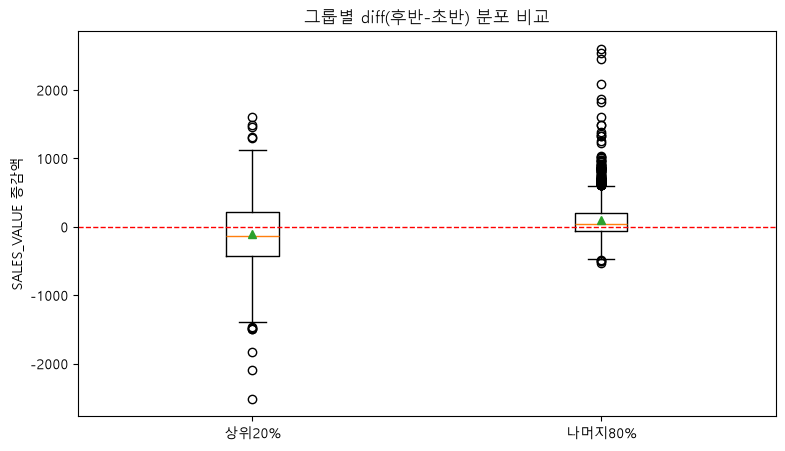

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot([top_diff, rest_diff], tick_labels=["상위20%", "나머지80%"], showmeans=True)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_title("그룹별 diff(후반-초반) 분포 비교")
ax.set_ylabel("SALES_VALUE 증감액")
plt.show()


## 9. 다음 단계

- H4-1의 세 번째 관점(매출 비중 자체의 변화)은 별도 부트스트랩 CI로 처리 예정 — 여기 3개 검정과 함께 총 4개 검정이 되면 본페로니 분모(N_TESTS)도 4로 업데이트 필요
- H4-2(신규/재활성화 교차분석)는 H1 라벨링 확정 후 이어서 진행
- 결론(6단계) 작성 시, H4-1은 원래 방향이 아니라 "수렴 패턴"으로 서술 방향 조정 필요


## 10. 검정 D — 매출 비중(share) 자체의 변화 (부트스트랩, H4-1 세 번째 관점)

지금까지(검정 A/B/C)는 "금액이 얼마나 늘고 줄었나"를 봤다면, 이번엔 "**전체 매출에서 상위20%가 차지하는 몫(%) 자체가 커졌는가**"를 본다.
가구 단위 값이 아니라 시점마다 하나씩만 나오는 값(비중)이라 Wilcoxon/Mann-Whitney를 쓸 수 없고, 부트스트랩으로 신뢰구간을 직접 계산한다.

**주의**: group(상위20%/나머지) 라벨은 원본 데이터의 초반 지출액 기준으로 이미 고정되어 있고, 재표본화 과정에서 다시 계산하지 않는다 — 순환논리 방지.


In [11]:
def compute_share(df_subset):
    """패널(가구 x 초반/후반/group)에서 상위20% 그룹의 매출 비중(초반, 후반)을 계산"""
    total_early = df_subset["sales_early"].sum()
    total_late  = df_subset["sales_late"].sum()
    top_early = df_subset.loc[df_subset["group"] == "상위20%", "sales_early"].sum()
    top_late  = df_subset.loc[df_subset["group"] == "상위20%", "sales_late"].sum()

    share_early = top_early / total_early
    share_late  = top_late / total_late
    return share_early, share_late

# 원본 데이터 기준 실제 비중
obs_share_early, obs_share_late = compute_share(panel)
obs_share_diff = obs_share_late - obs_share_early

print(f"초반 상위20% 매출 비중: {obs_share_early*100:.2f}%")
print(f"후반 상위20% 매출 비중: {obs_share_late*100:.2f}%")
print(f"비중 변화(후반-초반): {obs_share_diff*100:+.2f}%p")


초반 상위20% 매출 비중: 54.87%
후반 상위20% 매출 비중: 41.96%
비중 변화(후반-초반): -12.91%p


In [12]:
# 부트스트랩: 가구를 복원추출로 재표본화 (group 라벨은 고정된 채로 유지)
n_households = len(panel)
boot_share_diffs = np.empty(N_BOOT)

panel_reset = panel.reset_index()  # household_key를 컬럼으로 (샘플링 편의)

for i in range(N_BOOT):
    boot_idx = np.random.choice(panel_reset.index, size=n_households, replace=True)
    boot_sample = panel_reset.loc[boot_idx]
    s_early, s_late = compute_share(boot_sample)
    boot_share_diffs[i] = s_late - s_early

ci_share = np.percentile(boot_share_diffs, [2.5, 97.5])

print(f"부트스트랩 반복 횟수: {N_BOOT}")
print(f"관측된 비중 변화: {obs_share_diff*100:+.2f}%p")
print(f"95% 부트스트랩 CI: ({ci_share[0]*100:+.2f}%p, {ci_share[1]*100:+.2f}%p)")

zero_in_ci = ci_share[0] <= 0 <= ci_share[1]
print(f"\nCI가 0을 포함하는가: {zero_in_ci}")
if zero_in_ci:
    print("→ 비중 변화가 통계적으로 유의미하다고 보기 어려움")
else:
    direction = "감소" if obs_share_diff < 0 else "증가"
    print(f"→ 비중이 유의미하게 {direction}함 (0을 포함하지 않는 신뢰구간)")


부트스트랩 반복 횟수: 5000
관측된 비중 변화: -12.91%p
95% 부트스트랩 CI: (-14.74%p, -11.09%p)

CI가 0을 포함하는가: False
→ 비중이 유의미하게 감소함 (0을 포함하지 않는 신뢰구간)


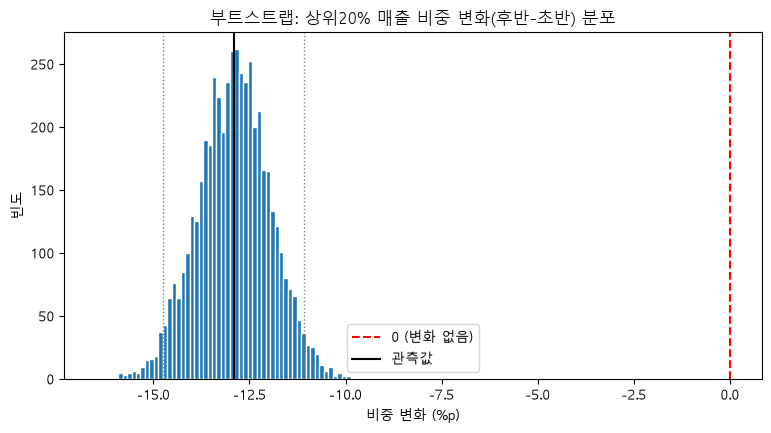

In [13]:
# 부트스트랩 분포 시각화
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(boot_share_diffs * 100, bins=60, edgecolor='white')
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='0 (변화 없음)')
ax.axvline(obs_share_diff * 100, color='black', linestyle='-', linewidth=1.5, label='관측값')
ax.axvline(ci_share[0]*100, color='gray', linestyle=':', linewidth=1)
ax.axvline(ci_share[1]*100, color='gray', linestyle=':', linewidth=1)
ax.set_title("부트스트랩: 상위20% 매출 비중 변화(후반-초반) 분포")
ax.set_xlabel("비중 변화 (%p)")
ax.set_ylabel("빈도")
ax.legend()
plt.show()


## 11. H4-1 최종 종합 (검정 A~D 전부)

본페로니 분모를 3→4로 업데이트하고, 검정 D까지 포함한 최종 결과표를 만든다.


In [15]:
N_TESTS_FINAL = 4
ALPHA_ADJ_FINAL = 0.05 / N_TESTS_FINAL
print(f"업데이트된 본페로니 보정 유의수준: {ALPHA_ADJ_FINAL:.4f} (0.05 / {N_TESTS_FINAL}개 검정)")

# 검정 A, B, C는 이미 나온 p-value를 재사용해서 새 기준으로 재판정
for name, p in [("A(상위20% 절대변화)", p_A), ("B(나머지80% 절대변화)", p_B), ("C(그룹간 차이)", p_C)]:
    sig = "유의" if p < ALPHA_ADJ_FINAL else "비유의"
    print(f"{name}: p={p:.6f} → {sig}")

# 검정 D는 CI 기반이라 p-value 대신 '0 포함 여부'로 판정 (동일 엄격도)
print(f"D(비중 변화): CI=({ci_share[0]*100:+.2f}%p, {ci_share[1]*100:+.2f}%p) → "
      f"{'비유의(CI가 0 포함)' if zero_in_ci else '유의(CI가 0 미포함)'}")

업데이트된 본페로니 보정 유의수준: 0.0125 (0.05 / 4개 검정)
A(상위20% 절대변화): p=0.000020 → 유의
B(나머지80% 절대변화): p=0.000000 → 유의
C(그룹간 차이): p=0.000000 → 유의
D(비중 변화): CI=(-14.74%p, -11.09%p) → 유의(CI가 0 미포함)


## 12. H4-1 결론 정리

- 금액 기준(A, B, C): 상위20%는 유의하게 감소, 나머지80%는 유의하게 증가, 그룹 간 차이도 유의 → **수렴(convergence) 패턴**
- 비중 기준(D): 위 셀 결과를 보고 "그럼에도 매출 비중 자체는 유지/확대되는지" 최종 확인
- 두 관점(금액 vs 비중)의 결론이 같은 방향이면 H4-1은 확실히 기각, 다르면 "금액은 줄었지만 비중은 유지된다"는 절충적 결론으로 서술
